# 📊 Notebook 3: Exploratory Data Analysis
**Project:** TalentSight — Employee Attrition Intelligence Platform  
**Author:** Saheri  
**Date:** May 2026  

## Objective
Transform cleaned data into business intelligence. Every analysis in this notebook 
is framed around a question a CHRO would actually ask — not just "what does the 
data look like" but "what does this mean and what should we do about it?"

This notebook is structured around three core business questions:
1. **Who is leaving?** — demographic and role-based segmentation
2. **Why are they leaving?** — behavioural and organisational drivers  
3. **What is it costing?** — financial quantification of the attrition problem

All insights feed directly into the Power BI dashboard and the executive report.

## 0. Setup & Data Loading
Load the cleaned dataset from `data/processed/`. Note that `category` dtype 
is not preserved in CSV — ordinal columns are recast after loading.

In [1]:
#Import necessary libraries
import os
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load the dataset   
BASE_DIR = os.path.dirname(os.path.abspath('__file__'))
data = pd.read_csv(os.path.join(BASE_DIR, '..', 'data', 'processed', 'cleaned_employee_attrition.csv'))

## 1. Who Is Leaving?
We begin by profiling the employees most likely to leave across five demographic 
and role-based dimensions. The goal is to build a precise profile of the 
highest-risk employee segment that HR can target with retention interventions.

### 1.1 Attrition Rate by Department
**Business question:** Which department has the biggest retention problem — 
measured as a proportion of its own headcount, not raw numbers?

Note: Raw headcount comparisons are misleading here — R&D has 961 employees 
vs HR's 63. Attrition *rate* is the honest metric.

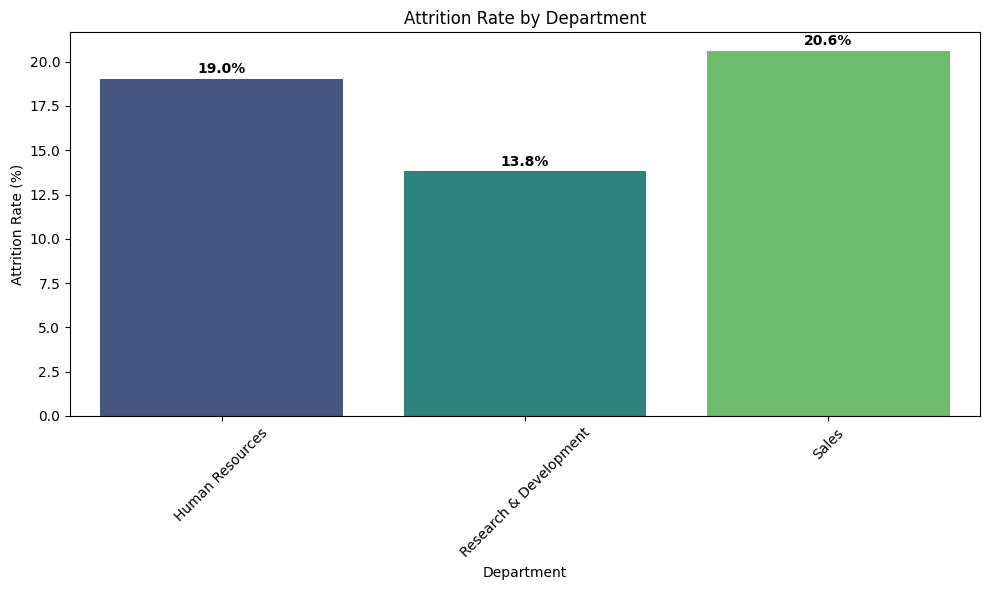

In [3]:
# Calculate attrition rate by department
attrition_by_department = data.groupby('Department')['Attrition'].mean().reset_index()
attrition_by_department['Attrition'] = attrition_by_department['Attrition'] * 100

# Plot attrition rate by department
plt.figure(figsize=(10, 6))
sns.barplot(x='Department', y='Attrition', data=attrition_by_department,
            hue='Department', palette='viridis', legend=False)

# Add value labels on bars
for i, v in enumerate(attrition_by_department['Attrition']):
    plt.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.title('Attrition Rate by Department')
plt.xlabel('Department')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Finding: Sales Is the Highest-Risk Department
Sales has the highest attrition rate at 20.6%, closely followed by HR at 19%. 
However, R&D's lower rate of 13.8% across 961 employees still represents the 
largest absolute headcount loss, making it the most costly department to ignore.

**Action:** Separate retention strategies are needed for Sales (high rate) 
and R&D (high volume) — a one-size-fits-all approach will underserve both.

### 1.2 Attrition Rate by Age Group
**Business question:** Is there a critical age window where attrition spikes, 
and does it correspond to early career employees who haven't yet built loyalty?

Age is binned into five career-stage segments to reveal meaningful patterns 
that raw age values would obscure.

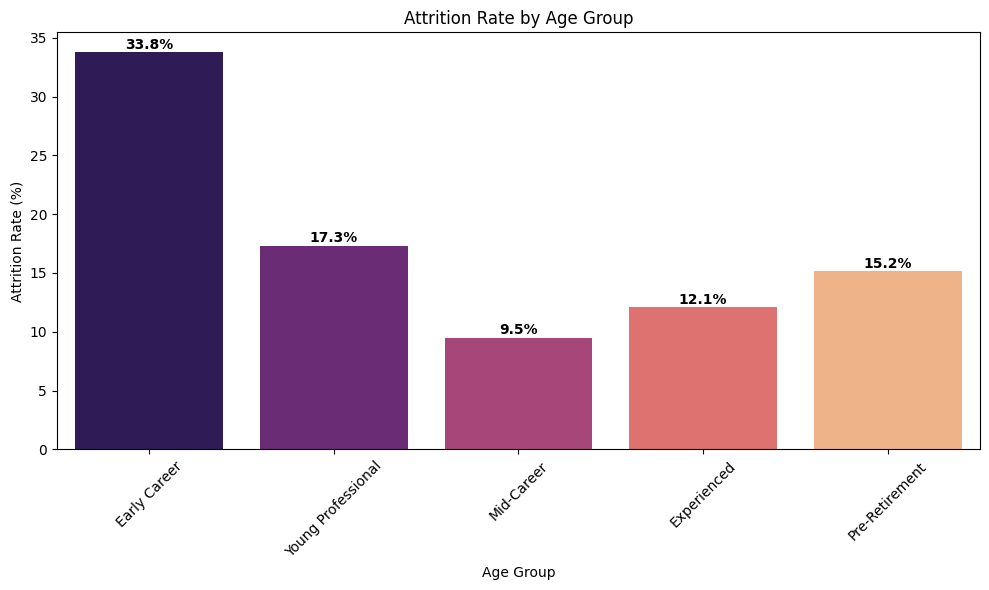

In [4]:
#Binning age into categories
age_bins = [18, 26, 36, 46, 56, np.inf]
age_labels = ['Early Career', 'Young Professional', 'Mid-Career', 'Experienced', 'Pre-Retirement']
data['AgeGroup'] = pd.cut(data['Age'], bins=age_bins, labels=age_labels)
# Calculate attrition rate by age group
attrition_by_age_group = data.groupby('AgeGroup', observed=True)['Attrition'].mean().reset_index()
attrition_by_age_group['Attrition'] = attrition_by_age_group['Attrition'] * 100
# Plot attrition rate by age group
plt.figure(figsize=(10, 6))
sns.barplot(x='AgeGroup', y='Attrition', data=attrition_by_age_group,
            hue='AgeGroup', palette='magma', legend=False)
# Add value labels on bars
for i, v in enumerate(attrition_by_age_group['Attrition']):
    plt.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')
plt.title('Attrition Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Finding: Early Career Employees Are Leaving at Alarming Rates
1 in 3 Early Career employees (18–25) leave the company, suggesting that 
onboarding and early career development programs are failing to build loyalty 
before competitors attract them away. Attrition drops sharply after age 35 
as employees become more settled in their careers and financial commitments increase.

**Action:** Retention investment should be front-loaded toward the first 
3 years of an employee's career — this is where the highest leverage exists.

### 1.3 Attrition Rate by Job Level & Job Role
**Business question:** Are junior or senior employees leaving — and which 
specific roles are bleeding talent at the highest rate?

These two dimensions are analysed together as they are closely related — 
job level indicates seniority while job role indicates function.

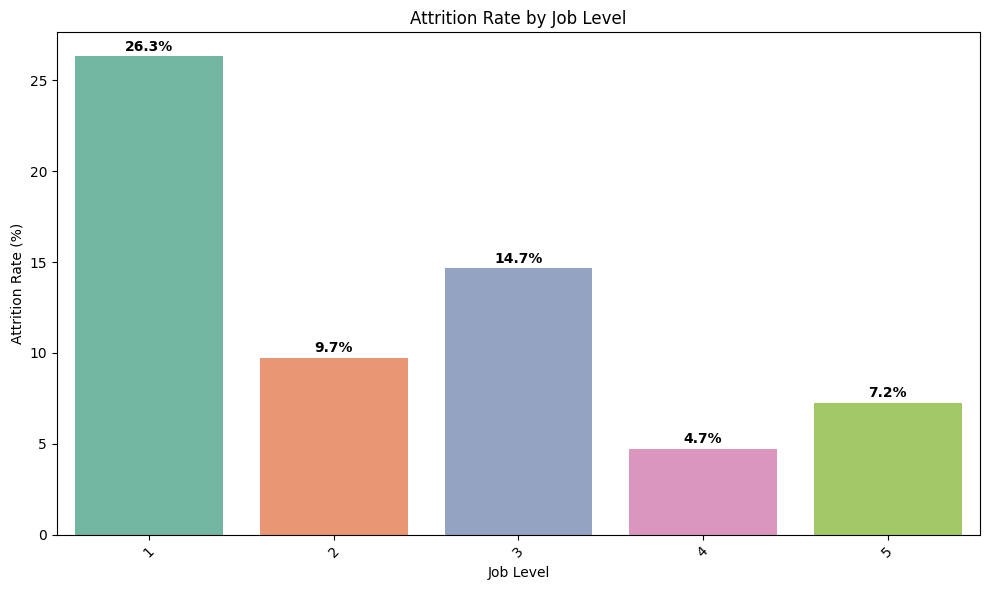

In [5]:
#Calculate attrition rate by job level
attrition_by_job_level = data.groupby('JobLevel')['Attrition'].mean().reset_index()
attrition_by_job_level['Attrition'] = attrition_by_job_level['Attrition'] * 100
# Plot attrition rate by job level
plt.figure(figsize=(10, 6))
sns.barplot(x='JobLevel', y='Attrition', data=attrition_by_job_level,
            hue='JobLevel', palette='Set2', legend=False)
# Add value labels on bars
for i, v in enumerate(attrition_by_job_level['Attrition']):
    plt.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')   
plt.title('Attrition Rate by Job Level')
plt.xlabel('Job Level')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()

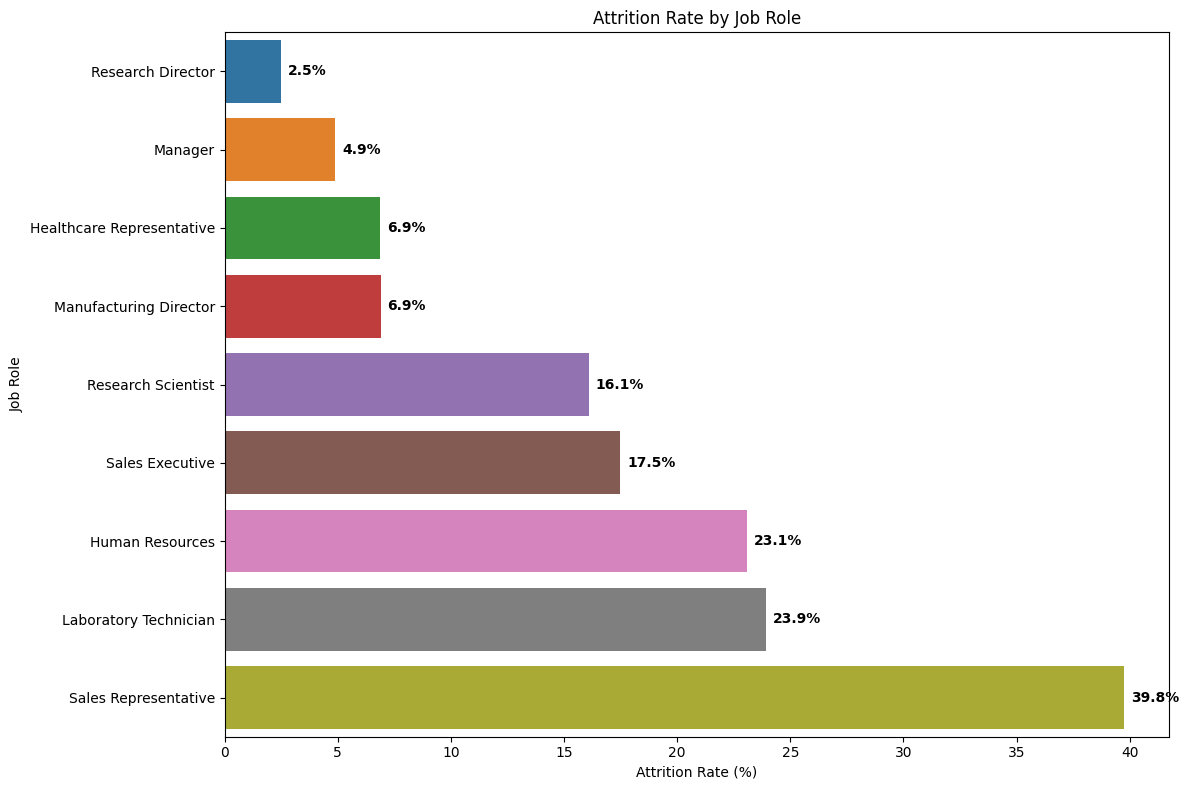

In [6]:
# Calculate attrition rate by job role
attrition_by_job_role = data.groupby('JobRole')['Attrition'].mean().reset_index()
attrition_by_job_role['Attrition'] = attrition_by_job_role['Attrition'] * 100
attrition_by_job_role = attrition_by_job_role.sort_values('Attrition', ascending=True)
# Plot attrition rate by job role through horizontal bar chart  
plt.figure(figsize=(12, 8))
sns.barplot(x='Attrition', y='JobRole', data=attrition_by_job_role,
            hue='JobRole', palette='tab10', legend=False)
# Add value labels on bars
for i, v in enumerate(attrition_by_job_role['Attrition']):
    plt.text(v + 0.3, i, f'{v:.1f}%', va='center', fontweight='bold')
plt.title('Attrition Rate by Job Role')
plt.xlabel('Attrition Rate (%)')
plt.ylabel('Job Role')
plt.tight_layout()
plt.show()

### Finding: Junior Roles and Sales Functions Are the Highest Risk
Entry-level employees (Job Level 1) leave at 26.3% — nearly 6× the rate 
of senior employees (Level 4 at 4.7%), suggesting that junior staff are 
leaving in search of better growth opportunities before the company can 
develop and retain them.

Sales Representatives have the highest attrition rate at 39.8% — nearly 
2.5× the company average — potentially driven by high-pressure targets, 
commission-based compensation structures, and frequent travel demands. 
This is confirmed in Section 2.6 where Business Travel × Job Role reveals 
Sales Representatives who travel frequently leave at 65.22%.

### 1.4 Attrition Rate by Marital Status
**Business question:** Does personal life stage influence attrition — 
and does it reinforce the early career risk profile we have identified?

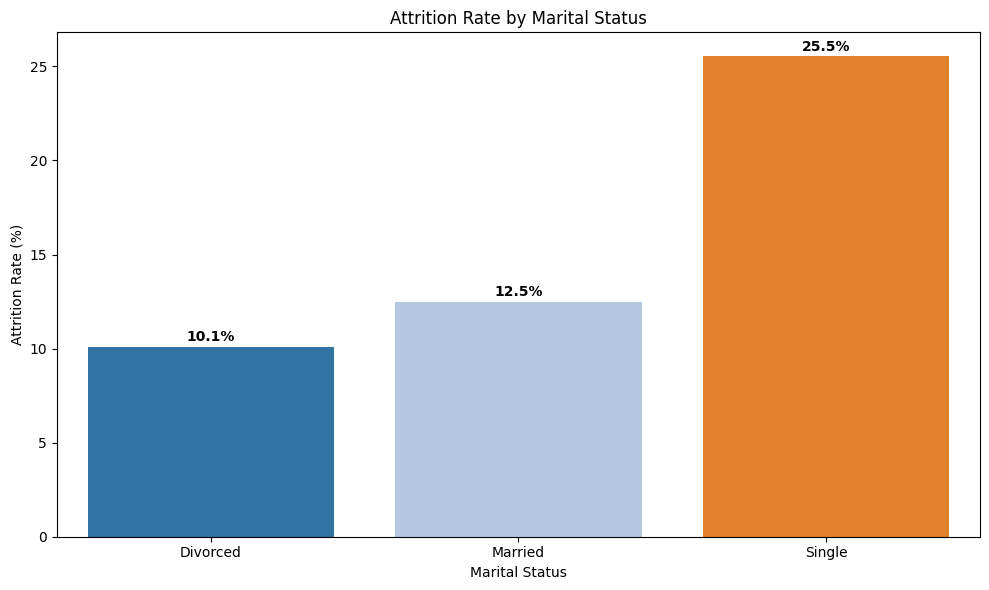

In [7]:
#Plotting attrition by marital status
attrition_by_marital_status = data.groupby('MaritalStatus')['Attrition'].mean().reset_index()
attrition_by_marital_status['Attrition'] = attrition_by_marital_status['Attrition'] * 100
plt.figure(figsize=(10, 6))
sns.barplot(x='MaritalStatus', y='Attrition', data=attrition_by_marital_status,
            hue='MaritalStatus', palette='tab20', legend=False)
# Add value labels on bars
for i, v in enumerate(attrition_by_marital_status['Attrition']):
    plt.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')
plt.title('Attrition Rate by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Attrition Rate (%)')
plt.tight_layout()
plt.show()

### Finding: Single Employees Are Significantly More Likely to Leave
Single employees leave at 25.5% — 2.5× the rate of divorced employees 
(10.1%) — reinforcing the pattern that employees in early life stages 
prioritise career growth and mobility over stability, compounding the 
Early Career and Job Level 1 attrition risk identified above.

### Who Is Leaving — Summary Profile
> *The highest-risk employee is an Early Career (18–25), Level 1 Sales 
> Representative who is single — with approximately a 1 in 3 chance of leaving.*

This profile forms the primary target segment for all retention interventions 
recommended in the executive report.

## 2. Why Are They Leaving?
Having identified *who* is leaving, we now investigate *why*. We begin with 
a correlation overview to identify the strongest numerical drivers of attrition, 
then deep dive into the most impactful variables, and finally cross-tabulate 
key variable pairs to uncover compounding effects.

### 2.1 Correlation of Numerical Features with Attrition
**Business question:** Which measurable factors are most strongly associated 
with attrition — and which ones are barely worth investigating?

This chart sets the agenda for the rest of Section 2. Variables with 
correlation stronger than ±0.10 are prioritised for deeper analysis.

**Important:** Correlation indicates association, not causation. A negative 
correlation means higher values of that variable are associated with *lower* 
attrition — it does not mean the variable directly causes employees to stay.

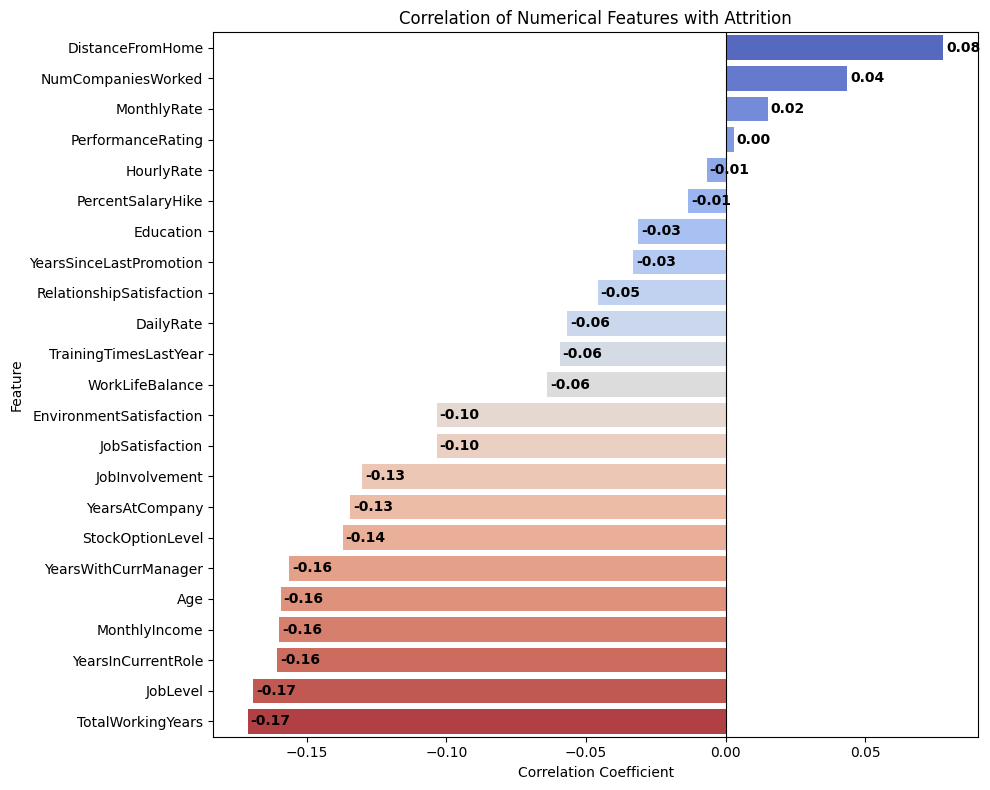

In [8]:
# Calculate correlation of numerical features with Attrition
# Drop Attrition itself and EmployeeNumber (ID column) to keep only meaningful features
numerical_features = data.select_dtypes(include=[np.number]).columns.tolist()
correlation_with_attrition = (data[numerical_features]
                              .corr()['Attrition']
                              .drop(['Attrition', 'EmployeeNumber'])
                              .sort_values(ascending=False)
                              .reset_index())
correlation_with_attrition.columns = ['Feature', 'Correlation']

# Plot horizontal bar chart of correlation coefficients
plt.figure(figsize=(10, 8))
sns.barplot(x='Correlation', y='Feature', data=correlation_with_attrition,
            hue='Feature', palette='coolwarm', legend=False)

# Add value labels on bars
for i, v in enumerate(correlation_with_attrition['Correlation']):
    plt.text(v + 0.001, i, f'{v:.2f}', va='center', fontweight='bold')

plt.title('Correlation of Numerical Features with Attrition')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Feature')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

### Finding: Seniority and Tenure Are the Strongest Retention Factors
The strongest negative correlations with attrition are `TotalWorkingYears` 
(-0.17), `JobLevel` (-0.17), `MonthlyIncome` (-0.16), and `YearsInCurrentRole` 
(-0.16) — collectively suggesting that experienced, senior, and well-compensated 
employees are significantly less likely to leave, making early career investment 
the highest-leverage retention strategy.

Note: `OverTime` does not appear in this chart as it is stored as a categorical 
variable (Yes/No) and is analysed separately in Section 2.3.

### 2.2 Compensation & Benefits vs Attrition
**Business question:** Are attrited employees earning less than those who 
stayed — and does equity compensation act as a meaningful retention tool?

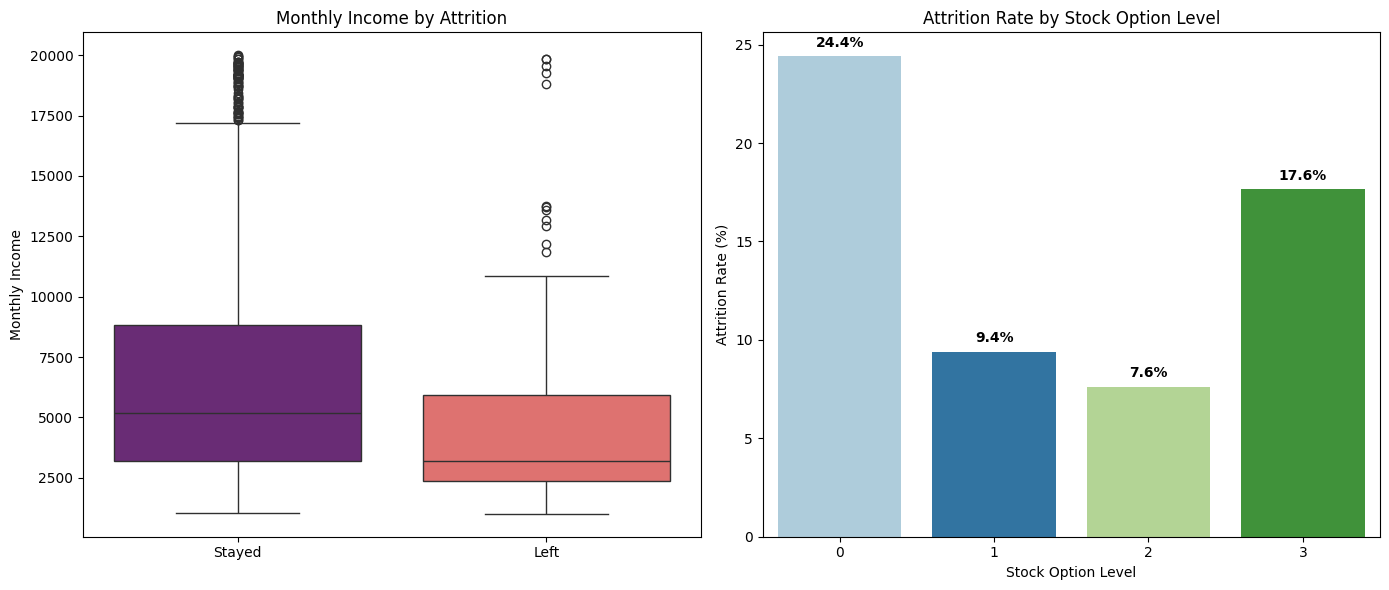

In [9]:
# Compensation & Benefits — Monthly Income and Stock Option Level vs Attrition
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left plot — Monthly Income box plot
sns.boxplot(x='Attrition', y='MonthlyIncome', data=data,
            hue='Attrition', palette='magma', legend=False, ax=axes[0])
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Stayed', 'Left'])
axes[0].set_title('Monthly Income by Attrition')
axes[0].set_xlabel('')
axes[0].set_ylabel('Monthly Income')

# Right plot — Attrition rate by Stock Option Level
attrition_by_stock = data.groupby('StockOptionLevel', observed=True)['Attrition'].mean().reset_index()
attrition_by_stock['Attrition'] = attrition_by_stock['Attrition'] * 100
sns.barplot(x='StockOptionLevel', y='Attrition', data=attrition_by_stock,
            hue='StockOptionLevel', palette='Paired', legend=False, ax=axes[1])
for i, v in enumerate(attrition_by_stock['Attrition']):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')
axes[1].set_title('Attrition Rate by Stock Option Level')
axes[1].set_xlabel('Stock Option Level')
axes[1].set_ylabel('Attrition Rate (%)')

plt.tight_layout()
plt.show()

### Finding: Undercompensation and Lack of Equity Are Key Flight Risk Factors
Attrited employees earn significantly lower median incomes than those who 
stayed, and employees with no stock options (Level 0) leave at 24.4% — 
nearly 3× the rate of those with any equity compensation — suggesting that 
employees who feel financially undercompensated and have no ownership stake 
in the company are most at risk of leaving.

**Action:** Extending stock option eligibility to Level 0 employees — 
even at a modest Level 1 grant — could reduce attrition in this segment 
by up to 15 percentage points based on the observed rate differential.

### 2.3 Overtime vs Attrition
**Business question:** Does working overtime significantly increase an 
employee's likelihood of leaving — and is this a manageable intervention point?

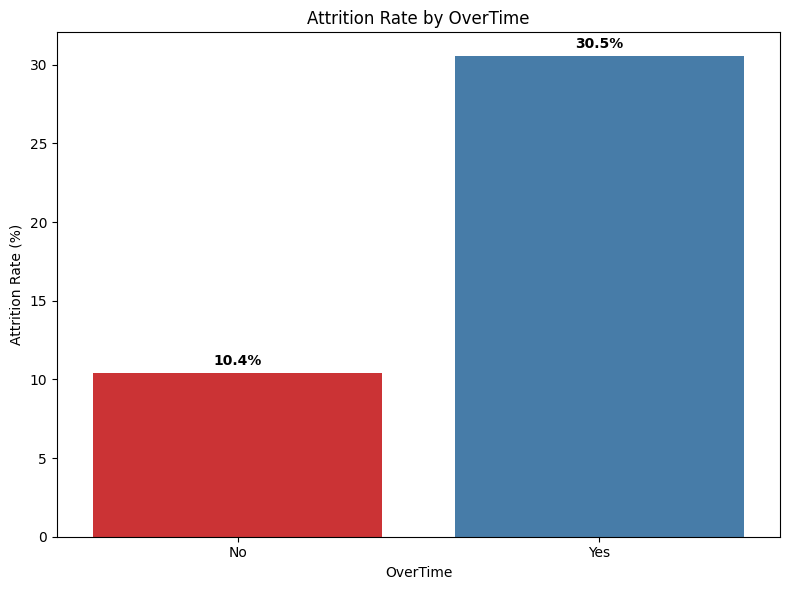

In [10]:
# Plotting attrition rate by OverTime
attrition_by_overtime = data.groupby('OverTime')['Attrition'].mean().reset_index()
attrition_by_overtime['Attrition'] = attrition_by_overtime['Attrition'] * 100
plt.figure(figsize=(8, 6))
sns.barplot(x='OverTime', y='Attrition', data=attrition_by_overtime,
            hue='OverTime', palette='Set1', legend=False)
for i, v in enumerate(attrition_by_overtime['Attrition']):  
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')
plt.title('Attrition Rate by OverTime') 
plt.xlabel('OverTime')
plt.ylabel('Attrition Rate (%)')    
plt.tight_layout()
plt.show()


### Finding: Overtime Is the Single Most Actionable Attrition Driver
Employees who work overtime leave at 30.5% — nearly 3× the rate of those 
who don't (10.4%) — indicating that unsustainable workload is a critical 
driver of attrition. Addressing overtime policies could immediately reduce 
flight risk for the 28% of the workforce currently working overtime.

**Action:** Implement overtime monitoring and mandatory compensatory time 
policies — particularly in Sales and R&D where attrition risk is already elevated.

### 2.4 Attrition Rate by Tenure (Years at Company)
**Business question:** Is there a critical tenure milestone where attrition 
spikes — and are we losing employees before they become fully productive?

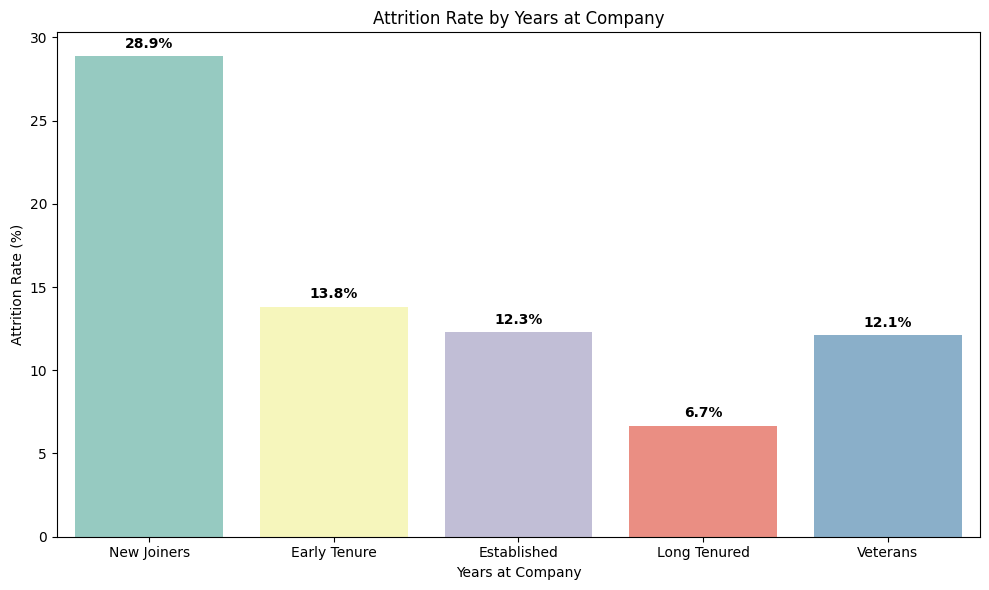

In [11]:
#Binning years at company into categories
tenure_bins = [0, 2, 5, 10, 20, 40]
tenure_labels = ['New Joiners', 'Early Tenure', 'Established', 'Long Tenured', 'Veterans']
data['YearsAtCompanyGroup'] = pd.cut(data['YearsAtCompany'], bins=tenure_bins, labels=tenure_labels)
# Calculate attrition rate by years at company group
attrition_by_years = data.groupby('YearsAtCompanyGroup', observed=True)['Attrition'].mean().reset_index()
attrition_by_years['Attrition'] = attrition_by_years['Attrition'] * 100
# Plot attrition rate by years at company group
plt.figure(figsize=(10, 6))
sns.barplot(x='YearsAtCompanyGroup', y='Attrition', data=attrition_by_years,
            hue='YearsAtCompanyGroup', palette='Set3', legend=False)
for i, v in enumerate(attrition_by_years['Attrition']):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')
plt.title('Attrition Rate by Years at Company')
plt.xlabel('Years at Company')
plt.ylabel('Attrition Rate (%)')
plt.tight_layout()
plt.show()

### Finding: The First Two Years Are the Most Critical Retention Window
28.9% of New Joiners (0–2 years) leave within their first two years — nearly 
double the rate of Established employees (6–10 years at 12.3%) — indicating 
a critical onboarding failure window where the company loses almost 1 in 3 
new hires before they become fully productive.

Attrition drops sharply after 5 years, confirming that loyalty builds 
quickly once employees cross this threshold.

**Action:** Structured 90-day, 6-month, and 12-month onboarding checkpoints 
with dedicated mentorship could significantly reduce New Joiner attrition.

### 2.5 Attrition Rate by Environment Satisfaction
**Business question:** Does workplace environment and culture influence 
attrition — and at what satisfaction threshold does the risk spike?

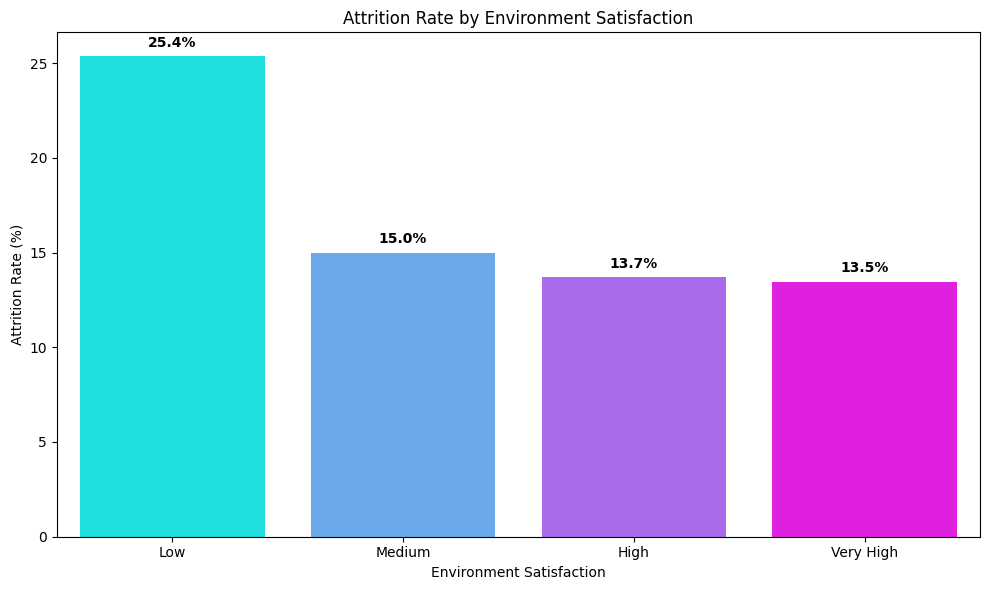

In [12]:
#Plotting Environment Satisfaction vs Attrition
attrition_by_env_satisfaction = data.groupby('EnvironmentSatisfaction', observed=True)['Attrition'].mean().reset_index()
attrition_by_env_satisfaction['Attrition'] = attrition_by_env_satisfaction['Attrition'] * 100
plt.figure(figsize=(10, 6)) 
sns.barplot(x='EnvironmentSatisfaction', y='Attrition', data=attrition_by_env_satisfaction,
            hue='EnvironmentSatisfaction', palette='cool', legend=False)
for i, v in enumerate(attrition_by_env_satisfaction['Attrition']):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')
plt.title('Attrition Rate by Environment Satisfaction')
plt.xlabel('Environment Satisfaction')
plt.ylabel('Attrition Rate (%)')
plt.xticks([0, 1, 2, 3], ['Low', 'Medium', 'High', 'Very High'])
plt.tight_layout()
plt.show()

### Finding: Low Environment Satisfaction Doubles Attrition Risk
Employees with low environment satisfaction leave at 25.4% — nearly double 
the rate of those with high satisfaction (13.7%) — suggesting that workplace 
culture, physical environment, and team dynamics are significant retention 
levers that management can directly influence through targeted culture initiatives.

**Action:** Annual culture surveys with mandatory follow-up action plans 
at department level, with particular focus on onboarding cohorts who are 
most sensitive to environment in their first year.

### 2.6 Further Investigation — Cross-Tabulation Analysis
The following four analyses cross-tabulate pairs of variables to uncover 
**compounding attrition effects** that individual variable analysis cannot reveal.

Each heatmap shows attrition rate for every combination of two variables — 
darker cells indicate higher attrition risk. These findings directly inform 
the interaction features built in `05_Feature_Engineering.ipynb`.

#### 2.6.1 Does Overtime Compound Poor Work-Life Balance?
**Hypothesis:** Employees with poor work-life balance who also work overtime 
face a compounding attrition risk that is greater than either factor alone.

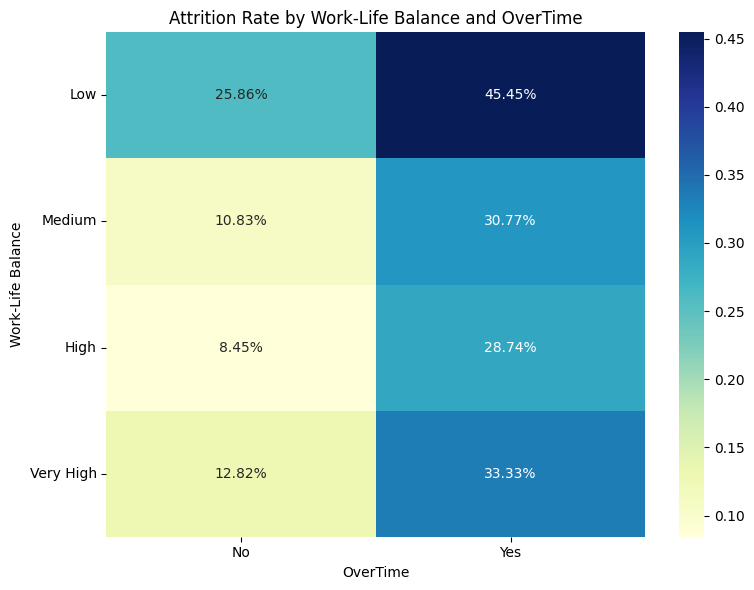

In [13]:
# Heatmap: Attrition rate by Work-Life Balance and OverTime
# Reveals whether overtime compounds poor work-life balance as an attrition driver
heatmap_data = data.groupby(['WorkLifeBalance', 'OverTime'], observed=True)['Attrition'].mean().reset_index()
heatmap_pivot = heatmap_data.pivot(index='WorkLifeBalance', columns='OverTime', values='Attrition')

plt.figure(figsize=(8, 6))
ax = sns.heatmap(heatmap_pivot, annot=True, fmt='.2%', cmap='YlGnBu')

# Replace numeric y-axis labels with meaningful labels
ax.set_yticklabels(['Low', 'Medium', 'High', 'Very High'], rotation=0)

plt.title('Attrition Rate by Work-Life Balance and OverTime')
plt.xlabel('OverTime')
plt.ylabel('Work-Life Balance')
plt.tight_layout()
plt.show()

#### Finding: Overtime and Poor Work-Life Balance Create a Critical Risk Zone
Employees with Low work-life balance who also work overtime leave at **45.45%** — 
nearly 1 in 2. This is the single highest-risk combination in the entire dataset.

Even employees with Very High work-life balance leave at 33.33% when forced 
to work overtime — suggesting that overtime damages retention regardless of 
how employees feel about their work-life balance generally.

**Action:** Overtime reduction should be the single highest-priority 
intervention, particularly for employees already reporting low work-life balance.

#### 2.6.2 Does Frequent Travel Drive Sales Representative Attrition?
**Hypothesis:** The extremely high attrition rate of Sales Representatives 
(39.8%) is driven primarily by frequent travel demands rather than 
role-specific dissatisfaction.

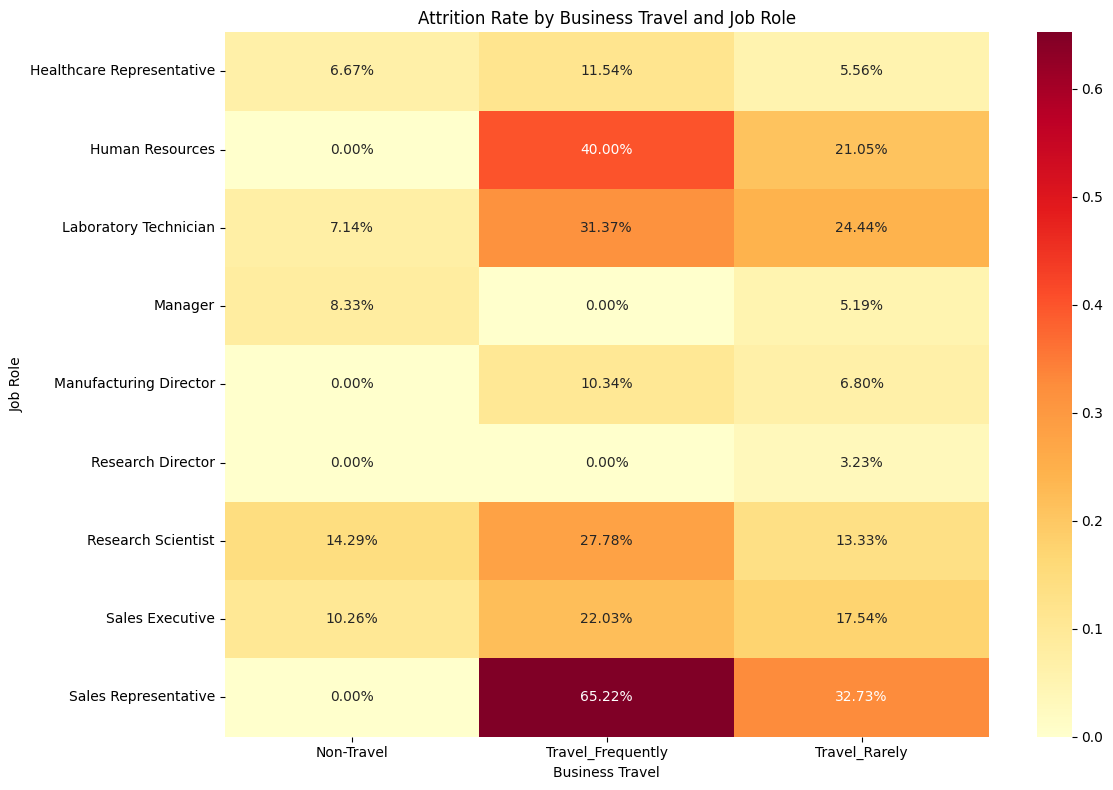

In [14]:
#Heatmap: Attrition rate by Bussiness Travel and Job Role
# Reveals if certain job roles with frequent travel have higher attrition
heatmap_data = data.groupby(['BusinessTravel', 'JobRole'], observed=True)['Attrition'].mean().reset_index()
heatmap_pivot = heatmap_data.pivot(index='JobRole', columns='BusinessTravel', values='Attrition')
plt.figure(figsize=(12, 8))
ax = sns.heatmap(heatmap_pivot, annot=True, fmt='.2%', cmap='YlOrRd')
plt.title('Attrition Rate by Business Travel and Job Role')
plt.xlabel('Business Travel')
plt.ylabel('Job Role')
plt.tight_layout()
plt.show()

#### Finding: Frequent Travel Is the Primary Driver of Sales Representative Attrition
Sales Representatives who travel frequently leave at an extraordinary **65.22%** — 
nearly 2 in 3. This single finding explains almost entirely why Sales 
Representatives had the highest overall attrition rate in Section 1.3.

Crucially, Sales Representatives who do not travel show 0.00% attrition — 
confirming that travel, not the role itself, is the root cause.

**Action:** Restructuring Sales Representative travel requirements — through 
territory redesign, virtual client meetings, or travel compensation — could 
dramatically reduce attrition in this role.

#### 2.6.3 Which Department Is Most Affected by Low Environment Satisfaction?
**Hypothesis:** The impact of low environment satisfaction on attrition 
is not uniform across departments — some departments may be more culturally 
toxic than others.

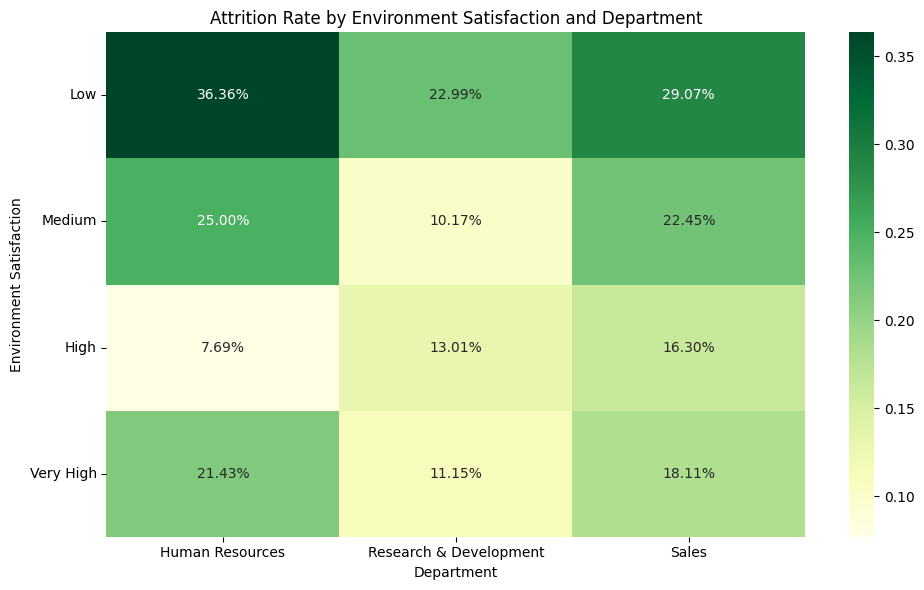

In [15]:
#Heatmap: Attrition rate by Environment Satisfaction and Department
# Reveals if certain departments with low environment satisfaction have higher attrition
heatmap_data = data.groupby(['EnvironmentSatisfaction', 'Department'], observed=True)['Attrition'].mean().reset_index()
heatmap_pivot = heatmap_data.pivot(index='EnvironmentSatisfaction', columns='Department', values='Attrition')
plt.figure(figsize=(10, 6))
ax = sns.heatmap(heatmap_pivot, annot=True, fmt='.2%', cmap='YlGn')
ax.set_yticklabels(['Low', 'Medium', 'High', 'Very High'], rotation=0)
plt.title('Attrition Rate by Environment Satisfaction and Department')
plt.xlabel('Department')
plt.ylabel('Environment Satisfaction')
plt.tight_layout()
plt.show()

#### Finding: HR Department Has the Most Toxic Low-Satisfaction Environment
HR employees with low environment satisfaction leave at **36.36%** — the 
highest cell in this matrix. However HR is a small department (63 employees) 
so this finding should be treated with caution.

More impactful at scale: R&D employees with low satisfaction leave at 22.99% 
across the largest department. Improving R&D environment satisfaction has the 
highest absolute retention impact of any culture initiative.

**Action:** Department-specific culture audits with targeted interventions — 
particularly in R&D where the combination of scale and satisfaction risk 
creates the largest financial exposure.

#### 2.6.4 Does Promotion Stagnation Drive Attrition Differently Across Career Stages?
**Hypothesis:** The impact of going without a promotion varies by career stage — 
Early Career employees may be more sensitive to promotion speed than 
experienced employees who have already reached senior levels.

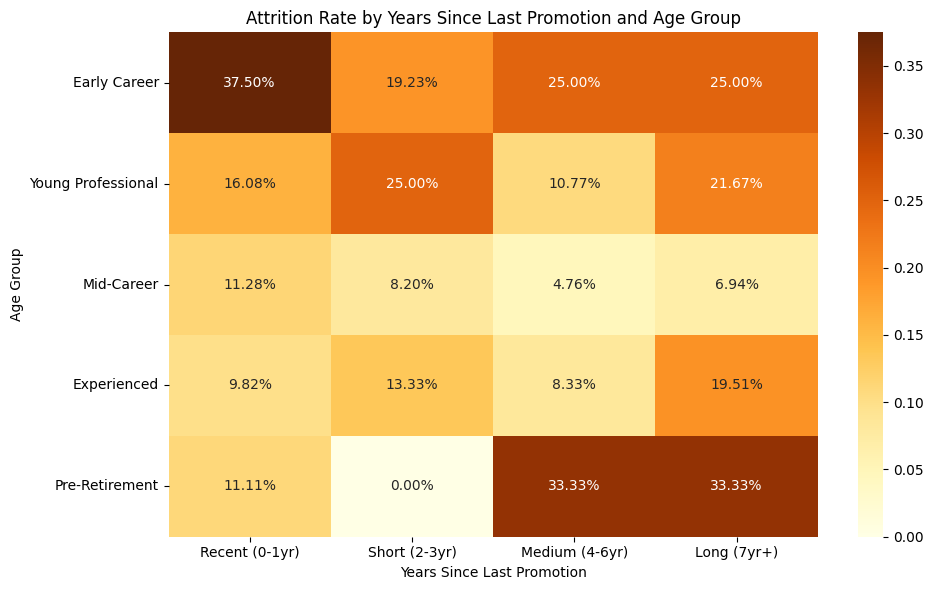

In [16]:
# Bin YearsSinceLastPromotion into meaningful groups
promotion_bins = [0, 1, 3, 6, 15]
promotion_labels = ['Recent (0-1yr)', 'Short (2-3yr)', 'Medium (4-6yr)', 'Long (7yr+)']
data['PromotionGroup'] = pd.cut(data['YearsSinceLastPromotion'], 
                                bins=promotion_bins, 
                                labels=promotion_labels, 
                                include_lowest=True)

# Heatmap: Attrition rate by PromotionGroup and AgeGroup
# Reveals if promotion stagnation impacts attrition differently across career stages
heatmap_data = data.groupby(['AgeGroup', 'PromotionGroup'], observed=True)['Attrition'].mean().reset_index()
heatmap_pivot = heatmap_data.pivot(index='AgeGroup', columns='PromotionGroup', values='Attrition')

plt.figure(figsize=(10, 6))
ax = sns.heatmap(heatmap_pivot, annot=True, fmt='.2%', cmap='YlOrBr')
ax.set_yticklabels(age_labels, rotation=0)
plt.title('Attrition Rate by Years Since Last Promotion and Age Group')
plt.xlabel('Years Since Last Promotion')
plt.ylabel('Age Group')
plt.tight_layout()
plt.show()

#### Finding: Early Career Employees Leave Even After Recent Promotions
Early Career employees with a recent promotion (0–1 year) still leave at 
**37.50%** — the highest rate in this matrix — suggesting that promotion 
alone is insufficient to retain early career talent. They need continuous 
growth signals, not just periodic title changes.

Young Professionals show peak attrition at 2–3 years without promotion 
(25.00%) — confirming a critical promotion window for this group.

Experienced employees (46–55) show elevated attrition after 7+ years 
without promotion (19.51%) — a different stagnation problem requiring 
lateral growth opportunities rather than vertical promotion.

**Action:** 
- For Early Career: quarterly growth conversations, not just annual reviews
- For Young Professionals: clear promotion timelines with defined criteria
- For Experienced: lateral mobility, mentorship roles, and project leadership

## 3. What Is It Costing?
Having identified who is leaving and why, we now quantify the financial 
impact of attrition. This section translates the human story into business 
numbers that justify retention investment to the CFO and board.

**Methodology:** Replacement cost is estimated at 1.5× annual salary per 
departing employee — a conservative industry standard that accounts for 
recruitment, onboarding, training, and lost productivity during the vacancy 
period.

In [17]:
#Total cost of attrition
attrited_employees = data[data['Attrition'] == 1]
replacement_cost = attrited_employees['MonthlyIncome'] * 12 * 1.5
total_cost = replacement_cost.sum()
print(f'Total Cost of Attrition: ${total_cost:,.2f}')

Total Cost of Attrition: $20,421,738.00


### Finding: Attrition Costs the Company an Estimated $20.4M Annually
Employee attrition costs the company an estimated $20.4M annually in 
replacement costs — representing a significant and largely preventable 
financial liability that dwarfs the cost of any retention program.

To put this in perspective: if a targeted retention program costing $2M 
reduces attrition by just 20%, it saves $4M — a 2× return on investment 
in year one alone.

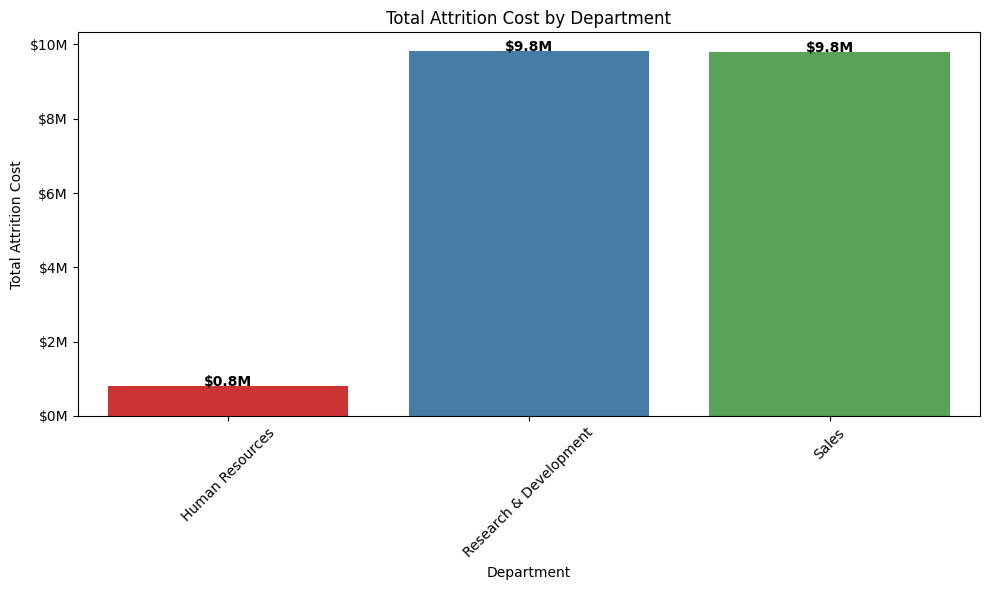

In [18]:
#Total cost of attrition by department
data['AttritionCost'] = data['MonthlyIncome'] * 12 * 1.5
attrition_cost_by_dept = data[data['Attrition'] == 1].groupby('Department')['AttritionCost'].sum().reset_index()
#Plotting total attrition cost by department
plt.figure(figsize=(10, 6)) 
sns.barplot(x='Department', y='AttritionCost', data=attrition_cost_by_dept,
            hue='Department', palette='Set1', legend=False)
for i, v in enumerate(attrition_cost_by_dept['AttritionCost']):
    plt.text(i, v + 0.5, f'${v/1e6:.1f}M', ha='center', fontweight='bold')   
plt.title('Total Attrition Cost by Department')
plt.xlabel('Department')
plt.ylabel('Total Attrition Cost')
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
plt.tight_layout()
plt.show()

### Finding: R&D and Sales Bear Equal Financial Burden Despite Different Attrition Rates
Despite R&D having the lowest attrition rate (13.8%), it matches Sales 
($9.8M each) in total replacement cost — because R&D employees command 
significantly higher salaries, making every departure more expensive even 
when fewer people leave.

**Implication:** A retention program focused purely on high-rate departments 
(Sales, HR) will miss half the financial impact. R&D requires equal attention 
despite its lower headline attrition rate.

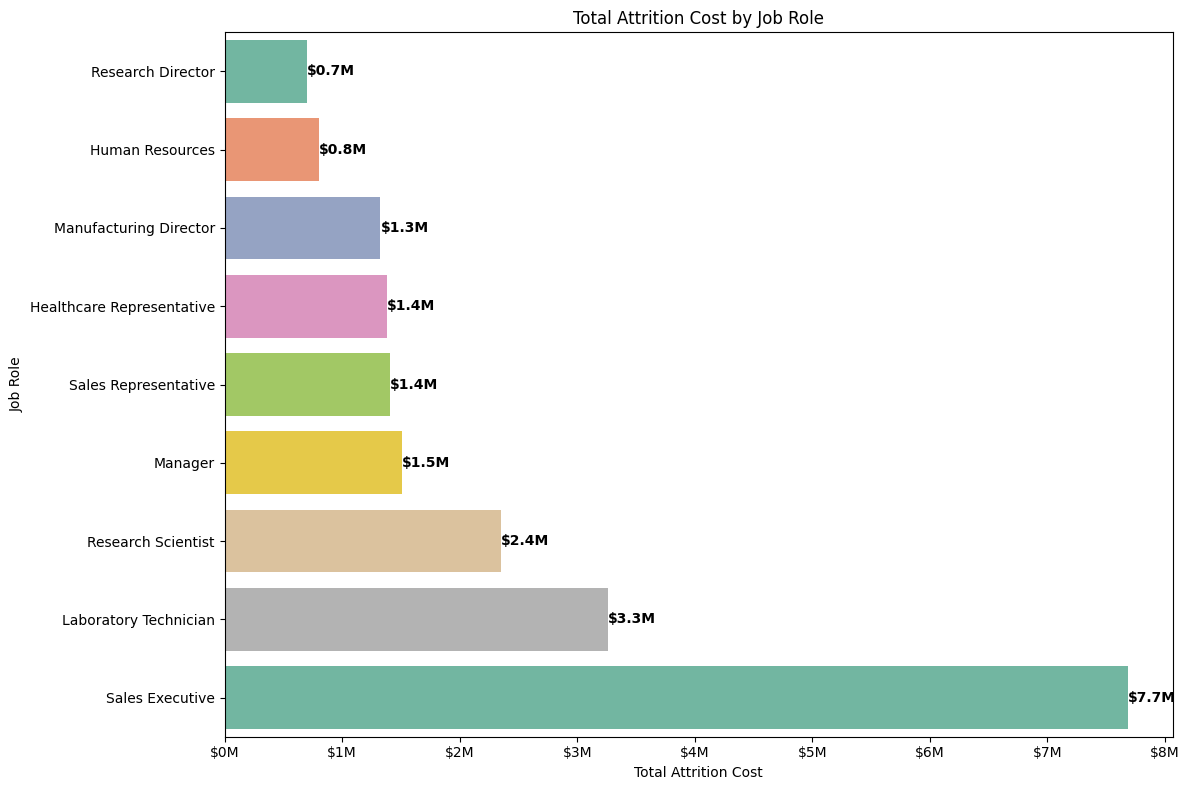

In [19]:
#Total cost of attrition by job role
attrition_cost_by_job_role = data[data['Attrition'] == 1].groupby('JobRole')['AttritionCost'].sum().reset_index()
attrition_cost_by_job_role = attrition_cost_by_job_role.sort_values('AttritionCost', ascending=True)
#Plotting total attrition cost by job role
plt.figure(figsize=(12, 8))
sns.barplot(x='AttritionCost', y='JobRole', data=attrition_cost_by_job_role,
            hue='JobRole', palette='Set2', legend=False)
for i, v in enumerate(attrition_cost_by_job_role['AttritionCost']):
    plt.text(v + 0.5, i, f'${v/1e6:.1f}M', va='center', fontweight='bold')
plt.title('Total Attrition Cost by Job Role')
plt.xlabel('Total Attrition Cost')
plt.ylabel('Job Role')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
plt.tight_layout()
plt.show()

### Finding: Sales Executives Represent the Single Most Expensive Attrition Segment
Sales Executives represent the single most expensive attrition segment at 
$7.7M — nearly 5× the cost of Sales Representatives ($1.4M) despite Sales 
Representatives having a much higher attrition rate (39.8% vs 17.5%) — 
because the higher salary of Sales Executives makes each individual departure 
significantly more costly to the business.

## 4. EDA Summary & Key Findings

| Dimension | Key Finding | Recommended Action |
|---|---|---|
| Department | Sales (20.6%) and HR (19%) have highest rates | Separate retention strategies per department |
| Age Group | 1 in 3 Early Career employees leave | Front-load retention investment in first 3 years |
| Job Level | Level 1 leaves at 26.3% vs Level 4 at 4.7% | Growth path clarity for junior employees |
| Job Role | Sales Representatives at 39.8% | Reduce travel requirements |
| Marital Status | Single employees at 25.5% | Social connection and mentorship programs |
| Compensation | No stock options → 24.4% attrition | Extend equity to Level 0 employees |
| Overtime | Overtime workers leave at 3× the rate | Overtime monitoring and comp time policies |
| Tenure | 28.9% of New Joiners leave in 2 years | Structured onboarding checkpoints |
| Environment | Low satisfaction doubles attrition risk | Department-specific culture audits |
| Travel × Role | Sales Reps who travel frequently → 65.22% | Territory and travel restructuring |
| Overtime × WLB | Low WLB + Overtime → 45.45% | Overtime reduction as priority intervention |
| Total Cost | $20.4M annual replacement cost | Any retention program under $5M has positive ROI |

---

### Highest-Risk Employee Profile
> *Early Career (18–25), Level 1, single Sales Representative who works 
> overtime and travels frequently — attrition probability exceeds 50%.*

---

**Next:** `04_Data_Collection.ipynb` — BLS API, Glassdoor scraping, 
and synthetic payroll generation.